Machine Learning KNN

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import yfinance as yf


In [20]:
SPX = yf.download('^GSPC', start='2019-01-01', end='2024-10-15')

[*********************100%***********************]  1 of 1 completed


In [21]:
SPX['Return'] = SPX['Close'].pct_change()
SPX['MA_5'] = SPX['Close'].rolling(window=5).mean()
SPX['MA_10'] = SPX['Close'].rolling(window=10).mean()

SPX.dropna(inplace=True)

print(SPX.tail())

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2024-10-08  5719.140137  5757.600098  5714.560059  5751.129883  5751.129883   
2024-10-09  5751.799805  5796.799805  5745.020020  5792.040039  5792.040039   
2024-10-10  5778.359863  5795.029785  5764.759766  5780.049805  5780.049805   
2024-10-11  5775.089844  5822.129883  5775.089844  5815.029785  5815.029785   
2024-10-14  5829.810059  5871.410156  5829.569824  5859.850098  5859.850098   

                Volume    Return         MA_5        MA_10  
Date                                                        
2024-10-08  3393400000  0.009689  5721.523926  5728.464941  
2024-10-09  3650340000  0.007113  5738.023926  5735.442969  
2024-10-10  3208790000 -0.002070  5754.045898  5738.910937  
2024-10-11  3208720000  0.006052  5766.837891  5746.596924  
2024-10-14  3005250000  0.007708  5799.619922  5756.333936  


In [22]:
X = SPX[['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_10']]
y = SPX['Adj Close']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Standardization of the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
model = RandomForestRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [27]:
#forecast on test set
y_pred = model.predict(X_test_scaled)


In [28]:
#Evaluate the model
mse = root_mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 22.420548840559896


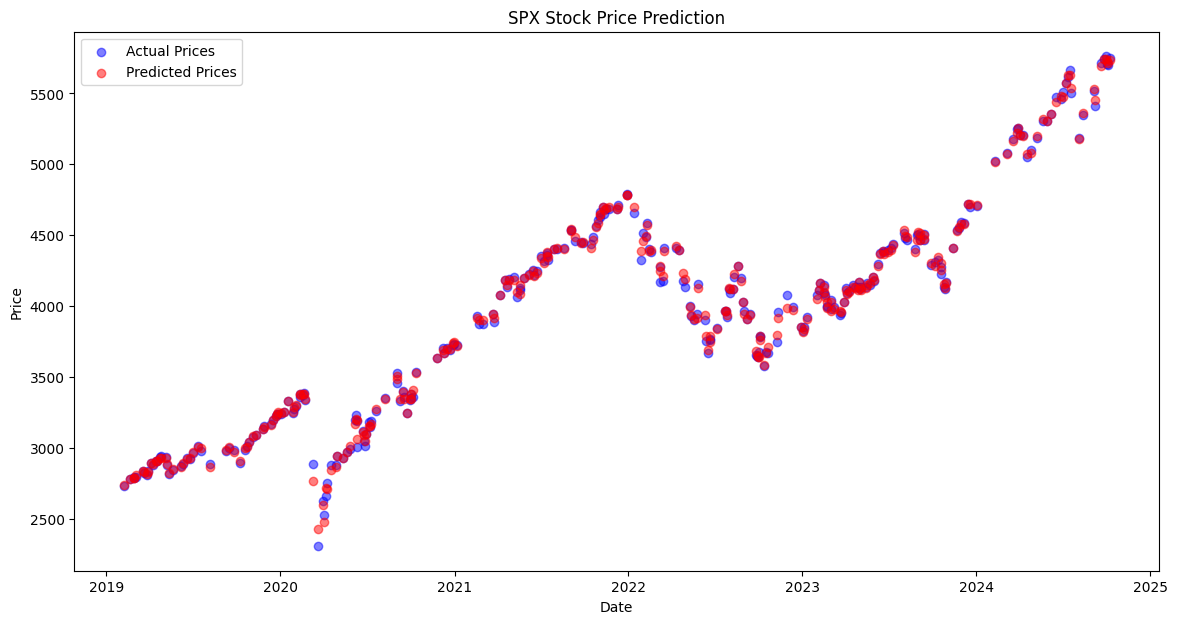

In [29]:
plt.figure(figsize=(14, 7))
plt.scatter(y_test.index, y_test, color='blue', label='Actual Prices', alpha=0.5)
plt.scatter(y_test.index, y_pred, color='red', label='Predicted Prices', alpha=0.5)
plt.legend()
plt.title('SPX Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [35]:
import csv
import random
import math
import operator
import datetime
import pandas as pd
import yfinance as yf
import plotly.graph_objs as go
import plotly.subplots as sp

In [36]:
# Function to split the data into a training dataset and test dataset in a ratio of 67/33
def loadDataset(filename, split, trainingSet=[], testSet=[], content_header=[]):
    with open(filename, 'r') as csvfile:
        lines = csv.reader(csvfile)
        dataset = list(lines)
        for x in range(len(dataset) - 1):
            for y in range(1, len(content_header) - 1):
                dataset[x][y] = float(dataset[x][y])
            if random.random() < split:
                trainingSet.append(dataset[x])
            else:
                testSet.append(dataset[x])

In [39]:
def euclideanDistance(instance1, instance2, length):
    distance = 0
    for x in range(1, length):
        distance += pow((instance1[x] - instance2[x]), 2)
    return math.sqrt(distance)

def getNeighbors(trainingSet, testInstance, k):
    distances = []
    length = len(testInstance) - 1
    for x in range(len(trainingSet)):
        dist = euclideanDistance(testInstance, trainingSet[x], length)
        distances.append((trainingSet[x], dist))
    distances.sort(key=operator.itemgetter(1))
    neighbors = []
    for x in range(k):
        neighbors.append(distances[x][0])
    return neighbors

def getResponse(neighbors):
    classVotes = {}
    for x in range(len(neighbors)):
        response = neighbors[x][-1]
        if response in classVotes:
            classVotes[response] += 1
        else:
            classVotes[response] = 1
    sortedVotes = sorted(classVotes.items(), key=operator.itemgetter(1), reverse=True)
    return sortedVotes[0][0]

def getAccuracy(testSet, predictions):
    correct = 0
    for x in range(len(testSet)):
        if testSet[x][-1] == predictions[x]:
            correct += 1
    return (correct / float(len(testSet))) * 100.0

def change(today, yest):
    if today > yest:
        return 'up'
    return 'down'

def getData(filename, stockname, startdate, enddate):
    stock = yf.download(stockname, start=startdate, end=enddate)
    print("Done making network call")

    first_time = True
    with open(filename, 'w', newline='') as pp:
        stockwriter = csv.writer(pp)
        for i in range(1, len(stock)):
            new_format_date = stock.index[i].strftime("%Y-%m-%d")
            if first_time:
                first_time = False
                prev_closing = stock['Adj Close'].iloc[i-1]
                continue
            stockwriter.writerow([new_format_date] + [stock['Open'].iloc[i]] + [stock['High'].iloc[i]] + [stock['Low'].iloc[i]] + [stock['Adj Close'].iloc[i]] + [change(stock['Adj Close'].iloc[i], prev_closing)])
            prev_closing = stock['Adj Close'].iloc[i]
    return stock  # Return the stock data for further use

def predictFor(k, filename, stockname, startdate, enddate, writeAgain, split):
    iv = ["date", "open", "high", "low", "yesterday closing adj", "state change"]
    trainingSet = []
    testSet = []
    totalCount = 0

    if writeAgain:
        print("Making a network request")
        stock = getData(filename, stockname, startdate, enddate)
    else:
        stock = None

    loadDataset(filename, split, trainingSet, testSet, iv)

    print("Predicting for ", stockname)
    print("Train: " + repr(len(trainingSet)))
    print("Test: " + repr(len(testSet)))
    totalCount += len(trainingSet) + len(testSet)
    print("Total: " + repr(totalCount))

    predict_and_get_accuracy(testSet, trainingSet, k, stockname, stock)

def predict_and_get_accuracy(testSet, trainingSet, k, stockname, stock):
    predictions = []
    price_predictions = []

    for x in range(len(testSet)):
        neighbors = getNeighbors(trainingSet, testSet[x], k)
        trend_result = getResponse(neighbors)
        predictions.append(trend_result)

        # Predict the price by averaging the neighbors' close prices
        price = sum(neighbor[4] for neighbor in neighbors) / len(neighbors)
        price_predictions.append(price)

    accuracy = getAccuracy(testSet, predictions)
    print('Accuracy: ' + repr(accuracy) + '%')

    dates = [datetime.datetime.strptime(testSet[dates][0], "%Y-%m-%d") for dates in range(len(testSet))]
    actual_trend = [1 if testSet[dates][-1] == "up" else -1 for dates in range(len(testSet))]
    predicted_trend = [1 if predictions[dates] == "up" else -1 for dates in range(len(testSet))]

    # Create subplots
    fig = sp.make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                           subplot_titles=("Stock movement of " + stockname,
                                           "Prediction vs Actual Trend of " + stockname,
                                           "Predicted vs Actual Prices"))

    # Add stock price trace
    fig.add_trace(go.Scatter(x=stock.index, y=stock["Adj Close"], mode='lines', name='Actual Stock Price', line=dict(color='blue', width=2)), row=1, col=1)

    # Add actual trend trace
    fig.add_trace(go.Scatter(x=dates, y=actual_trend, mode='lines+markers', name='Actual Trend', line=dict(color='blue', width=3)), row=2, col=1)

    # Add predicted trend trace
    fig.add_trace(go.Scatter(x=dates, y=predicted_trend, mode='lines+markers', name='Predicted Trend', line=dict(color='red', dash='dash', width=3)), row=2, col=1)

    # Add actual vs predicted prices
    fig.add_trace(go.Scatter(x=dates, y=[testSet[dates][4] for dates in range(len(testSet))], mode='lines+markers', name='Actual Prices', line=dict(color='blue', width=2)), row=3, col=1)
    fig.add_trace(go.Scatter(x=dates, y=price_predictions, mode='lines+markers', name='Predicted Prices', line=dict(color='red', dash='dash', width=2)), row=3, col=1)

    # Update layout
    fig.update_layout(height=1300, width=1700, title_text=f"Stock Prediction Analysis for {stockname}", showlegend=True)
    fig.update_yaxes(title_text="Adjusted Close Price", row=1, col=1)
    fig.update_yaxes(title_text="Trend", row=2, col=1)
    fig.update_yaxes(title_text="Price", row=3, col=1)
    fig.update_xaxes(title_text="Date", row=3, col=1)

    # Show plot
    fig.show()

def main():
    split = 0.67
    startdate = datetime.datetime(2022, 1, 1)
    enddate = datetime.date.today()

    # Predicting for Apple Inc. (AAPL)
    predictFor(5, 'SPX.csv', '^GSPC', startdate, enddate, True, split)

main()

[*********************100%***********************]  1 of 1 completed

Making a network request
Done making network call


Predicting for  ^GSPC
Train: 473
Test: 227
Total: 700
Accuracy: 69.16299559471366%
